In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pyreadr

from idd_forecast_mbp import constants as rfc
RAW_DATA_PATH = rfc.RAW_DATA_PATH
PROCESSED_DATA_PATH = rfc.PROCESSED_DATA_PATH
RR_DATA_PATH = rfc.RR_PATH / 'data/02-processed-data'

full_suit_df_path = PROCESSED_DATA_PATH / 'malaria_temp_suitabilities_df.parquet'

# Load posterior samples
oswaldov_data_path = RAW_DATA_PATH / 'temperature_suitability/malaria/oswaldov/data'
samps = pyreadr.read_r(f'{oswaldov_data_path}/Angamb_Pfalc_samps.Rsave')

mordecai_df = pd.read_csv(RR_DATA_PATH / 'mal_den_temp_suitability_df.csv')
mordecai_df = mordecai_df[mordecai_df['cause'] == 'malaria'].copy()
mordecai_df = mordecai_df[['temperature', 'rel_suit']]

# Create full temperature range
delta_t = 1 / 100.0
full_temp_range = np.arange(15.0, 45.0 + delta_t, delta_t)
baseline_suit_df = pd.DataFrame({'temperature': np.round(full_temp_range, 2)})

# Interpolate mordecai data onto full temperature range
baseline_suit_df['rel_suit'] = np.interp(
    baseline_suit_df['temperature'], 
    mordecai_df['temperature'], 
    mordecai_df['rel_suit'],
    left=0,   # Fill temps below 17.55°C with 0
    right=0   # Fill temps above 33.45°C with 0
)
baseline_suit_df['method'] = 'mordecai'

In [2]:
# TPC Functions
def briere(temps, c, T0, Tm):
    """Brière model for MDR, PDR, a (biting rate)"""
    result = c * temps * (temps - T0) * np.sqrt(np.maximum(0, Tm - temps))
    result = np.where((temps > T0) & (temps < Tm), result, 0)
    return np.maximum(0, result)

def quad_down(temps, qd, T0, Tm, mult=1, truncate=False):
    """Concave-down quadratic for efd, e2a, bc
    
    truncate: if True, clip output to [0,1] (for probabilities like bc, pea)
    """
    result = -qd * (temps - T0) * (temps - Tm) * mult
    result = np.where((temps > T0) & (temps < Tm), result, 0)
    result = np.maximum(0, result)
    if truncate:
        result = np.clip(result, 0, 1)
    return result

def quad_up(temps, inter, n_slope, qd):
    """Concave-up quadratic for mu (mortality)"""
    return np.maximum(0, inter - n_slope * temps + qd * temps**2)

# S(T) suitability metric formula from the paper
def suitability(a, PDR, MDR, efd, pea, bc, mu):
    """S(T) = sqrt((a^2 * bc * (efd * pea * MDR / mu^2) * exp(-mu / PDR)) / mu)"""
    ec = 1e-6  # Small constant to avoid division by zero
    return np.sqrt((a**2 * bc * (efd * pea * MDR / (mu**2 + ec)) * np.exp(-mu / (PDR + ec))) / (mu + ec))

In [3]:
# Debug: Check all quadratic trait parameters
for trait_name, df_name in [('efd', 'efd.sampsgam'), ('e2a', 'e2a.sampsgam'), ('bc', 'bc.sampsgampf')]:
    df = samps[df_name]
    print(f"\n{trait_name} ({df_name}):")
    print(f"  qd: min={df['qd'].min():.6f}, max={df['qd'].max():.6f}, mean={df['qd'].mean():.6f}")
    print(f"  T0: min={df['T0'].min():.2f}, max={df['T0'].max():.2f}")
    print(f"  Tm: min={df['Tm'].min():.2f}, max={df['Tm'].max():.2f}")

# Test curves at sample 0
idx = 0
test_T = np.linspace(0, 50, 501)

print("\n--- Testing curves at sample 0 ---")
for trait_name, df_name, needs_mult in [('efd', 'efd.sampsgam', True), ('e2a', 'e2a.sampsgam', True), ('bc', 'bc.sampsgampf', True)]:
    df = samps[df_name]
    # Without mult=-1
    curve_no_mult = quad_down(test_T, df['qd'].iloc[idx], df['T0'].iloc[idx], df['Tm'].iloc[idx])
    # With mult=-1
    curve_mult = quad_down(test_T, df['qd'].iloc[idx], df['T0'].iloc[idx], df['Tm'].iloc[idx], mult=-1)
    print(f"{trait_name}: no mult max={curve_no_mult.max():.4f}, with mult=-1 max={curve_mult.max():.4f}")


efd (efd.sampsgam):
  qd: min=0.000452, max=4.977958, mean=1.275906
  T0: min=0.00, max=23.98
  Tm: min=25.04, max=45.00

e2a (e2a.sampsgam):
  qd: min=0.004360, max=0.023569, mean=0.009990
  T0: min=10.82, max=20.13
  Tm: min=30.50, max=37.28

bc (bc.sampsgampf):
  qd: min=-0.005435, max=-0.001148, mean=-0.002391
  T0: min=0.00, max=14.95
  Tm: min=36.37, max=44.97

--- Testing curves at sample 0 ---
efd: no mult max=60.2225, with mult=-1 max=0.0000
e2a: no mult max=0.7569, with mult=-1 max=0.0000
bc: no mult max=0.0000, with mult=-1 max=0.6307


Using 5000 thinned samples (every 20th of 100000)
Computing trait curves...
Done computing traits.


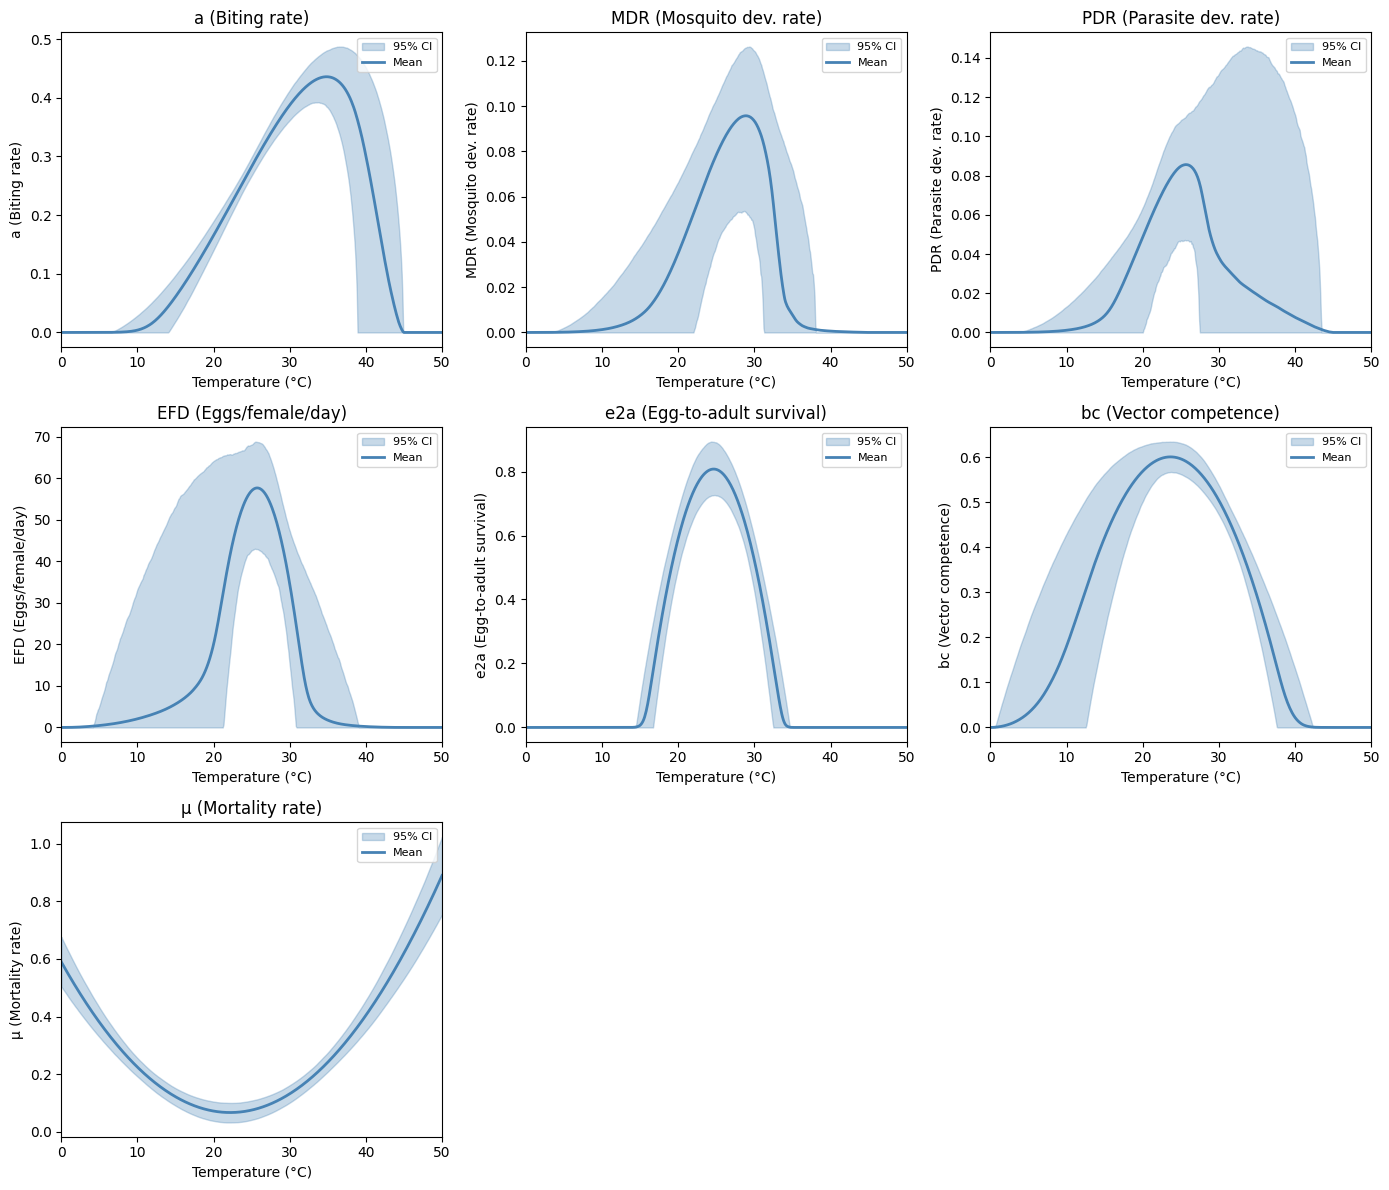

Computing S(T) curves...
  iteration 0
  iteration 500
  iteration 1000
  iteration 1500
  iteration 2000
  iteration 2500
  iteration 3000
  iteration 3500
  iteration 4000
  iteration 4500
Done computing S(T).


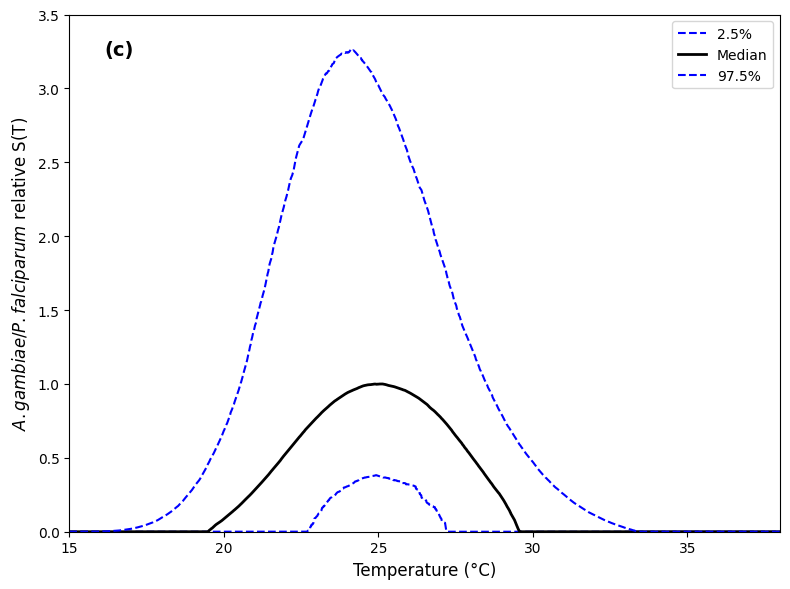

Max upper 97.5%: 3.26 (their figure: ~3.25)

Peak suitability temperature: 24.9°C (95% CI: 23.7-26.1°C)
Lower thermal limit: 19.5°C (95% CI: 15.6-22.5°C)
Upper thermal limit: 29.6°C (95% CI: 27.3-33.4°C)


In [4]:
# Temperature arrays (matches R: temp = seq(5,45,by=0.1))
T_traits = np.linspace(0, 50, 501)   # For individual trait plots
T_suit = baseline_suit_df['temperature'].values    

# Match R: thinned <- seq(1, n, by=20)
n_total = 100000
thinned = np.arange(0, n_total, 20)  # Every 20th sample (0-indexed)
n_samples = len(thinned)  # 5000 samples
print(f"Using {n_samples} thinned samples (every 20th of {n_total})")

def compute_trait_curves(temps, trait_name, func, params_df, param_names, mult=1, truncate=False):
    """Compute curves for thinned samples at given temperature array"""
    curves = np.zeros((n_samples, len(temps)))
    for j, i in enumerate(thinned):
        params = [params_df[p].iloc[i] for p in param_names]
        curves[j] = func(temps, *params, mult=mult, truncate=truncate) if 'mult' in func.__code__.co_varnames else func(temps, *params)
    return curves

# Compute all trait curves for visualization
print("Computing trait curves...")
traits = {
    'a (Biting rate)': compute_trait_curves(T_traits, 'a', briere, samps['a.sampsgam'], ['c', 'T0', 'Tm']),
    'MDR (Mosquito dev. rate)': compute_trait_curves(T_traits, 'MDR', briere, samps['MDR.sampsgam'], ['c', 'T0', 'Tm']),
    'PDR (Parasite dev. rate)': compute_trait_curves(T_traits, 'PDR', briere, samps['PDR.sampsgampf'], ['c', 'T0', 'Tm']),
    'EFD (Eggs/female/day)': compute_trait_curves(T_traits, 'efd', quad_down, samps['efd.sampsgam'], ['qd', 'T0', 'Tm']),
    'e2a (Egg-to-adult survival)': compute_trait_curves(T_traits, 'e2a', quad_down, samps['e2a.sampsgam'], ['qd', 'T0', 'Tm'], truncate=True),
    'bc (Vector competence)': compute_trait_curves(T_traits, 'bc', quad_down, samps['bc.sampsgampf'], ['qd', 'T0', 'Tm'], mult=-1, truncate=True),
    'μ (Mortality rate)': compute_trait_curves(T_traits, 'mu', quad_up, samps['mu.sampsgam'], ['inter', 'n.slope', 'qd']),
}
print("Done computing traits.")

# Plot all traits
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, (name, curves) in enumerate(traits.items()):
    ax = axes[i]
    mean = np.mean(curves, axis=0)
    lower = np.percentile(curves, 2.5, axis=0)
    upper = np.percentile(curves, 97.5, axis=0)
    
    ax.fill_between(T_traits, lower, upper, alpha=0.3, color='steelblue', label='95% CI')
    ax.plot(T_traits, mean, 'steelblue', lw=2, label='Mean')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel(name)
    ax.set_xlim(0, 50)
    ax.set_title(name)
    ax.legend(loc='upper right', fontsize=8)

for j in range(len(traits), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Compute S(T) for each thinned posterior sample (matches R loop)
print("Computing S(T) curves...")
ST_curves = np.zeros((n_samples, len(T_suit)))

ec = 1e-6  # matches R: ec<-0.000001

for j, i in enumerate(thinned):
    if j % 500 == 0:
        print(f"  iteration {j}")
    
    a_curve = briere(T_suit, samps['a.sampsgam']['c'].iloc[i], 
                             samps['a.sampsgam']['T0'].iloc[i], 
                             samps['a.sampsgam']['Tm'].iloc[i])
    
    PDR_curve = briere(T_suit, samps['PDR.sampsgampf']['c'].iloc[i],
                               samps['PDR.sampsgampf']['T0'].iloc[i],
                               samps['PDR.sampsgampf']['Tm'].iloc[i])
    
    MDR_curve = briere(T_suit, samps['MDR.sampsgam']['c'].iloc[i],
                               samps['MDR.sampsgam']['T0'].iloc[i],
                               samps['MDR.sampsgam']['Tm'].iloc[i])
    
    efd_curve = quad_down(T_suit, samps['efd.sampsgam']['qd'].iloc[i],
                                  samps['efd.sampsgam']['T0'].iloc[i],
                                  samps['efd.sampsgam']['Tm'].iloc[i])
    
    pea_curve = quad_down(T_suit, samps['e2a.sampsgam']['qd'].iloc[i],
                                  samps['e2a.sampsgam']['T0'].iloc[i],
                                  samps['e2a.sampsgam']['Tm'].iloc[i],
                                  truncate=True)
    
    bc_curve = quad_down(T_suit, samps['bc.sampsgampf']['qd'].iloc[i],
                                 samps['bc.sampsgampf']['T0'].iloc[i],
                                 samps['bc.sampsgampf']['Tm'].iloc[i],
                                 mult=-1, truncate=True)
    
    mu_curve = quad_up(T_suit, samps['mu.sampsgam']['inter'].iloc[i],
                               samps['mu.sampsgam']['n.slope'].iloc[i],
                               samps['mu.sampsgam']['qd'].iloc[i])
    
    # S(T) formula: ((a^2*bc*(efd*pea*MDR/mu^2)*exp(-mu/(PDR+ec)))/(mu+ec))^0.5
    ST_curves[j] = np.sqrt((a_curve**2 * bc_curve * (efd_curve * pea_curve * MDR_curve / (mu_curve**2 + ec)) * 
                            np.exp(-mu_curve / (PDR_curve + ec))) / (mu_curve + ec))

print("Done computing S(T).")

# Calculate statistics - use MEDIAN for normalization (matches their figure)
ST_median = np.nanmedian(ST_curves, axis=0)
ST_lower = np.nanpercentile(ST_curves, 2.5, axis=0)
ST_upper = np.nanpercentile(ST_curves, 97.5, axis=0)

# Normalize by max median S(T) - this gives upper CI of ~3.25 matching their figure
ST_scale = np.nanmax(ST_median)

# Plot relative S(T) matching their figure style
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(T_suit, ST_lower/ST_scale, 'b--', lw=1.5, label='2.5%')
ax.plot(T_suit, ST_median/ST_scale, 'k-', lw=2, label='Median')
ax.plot(T_suit, ST_upper/ST_scale, 'b--', lw=1.5, label='97.5%')
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel(r'$A. gambiae$/$P. falciparum$ relative S(T)', fontsize=12)
ax.text(0.05, 0.95, '(c)', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')
ax.set_xlim(15, 38)
ax.set_ylim(0, 3.5)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Max upper 97.5%: {np.nanmax(ST_upper/ST_scale):.2f} (their figure: ~3.25)")

# Calculate peak and transmission range from posterior
ST_peak = np.array([T_suit[np.argmax(ST_curves[j])] for j in range(n_samples)])
ST_min_temp = np.array([T_suit[ST_curves[j] > 0][0] if np.any(ST_curves[j] > 0) else np.nan for j in range(n_samples)])
ST_max_temp = np.array([T_suit[ST_curves[j] > 0][-1] if np.any(ST_curves[j] > 0) else np.nan for j in range(n_samples)])

print(f"\nPeak suitability temperature: {np.nanmedian(ST_peak):.1f}°C (95% CI: {np.nanpercentile(ST_peak, 2.5):.1f}-{np.nanpercentile(ST_peak, 97.5):.1f}°C)")
print(f"Lower thermal limit: {np.nanmedian(ST_min_temp):.1f}°C (95% CI: {np.nanpercentile(ST_min_temp, 2.5):.1f}-{np.nanpercentile(ST_min_temp, 97.5):.1f}°C)")
print(f"Upper thermal limit: {np.nanmedian(ST_max_temp):.1f}°C (95% CI: {np.nanpercentile(ST_max_temp, 2.5):.1f}-{np.nanpercentile(ST_max_temp, 97.5):.1f}°C)")

In [5]:
import xarray as xr

# Compute all trait curves at S(T) temperatures for the xarray dataset
print("Computing trait curves at S(T) temperatures...")
trait_arrays = {}

# Brière traits
for name, df_name in [('a', 'a.sampsgam'), ('MDR', 'MDR.sampsgam'), ('PDR', 'PDR.sampsgampf')]:
    curves = np.zeros((n_samples, len(T_suit)))
    for j, i in enumerate(thinned):
        curves[j] = briere(T_suit, samps[df_name]['c'].iloc[i], 
                                   samps[df_name]['T0'].iloc[i], 
                                   samps[df_name]['Tm'].iloc[i])
    trait_arrays[name] = curves

# Quadratic down traits
for name, df_name, kwargs in [('efd', 'efd.sampsgam', {}), 
                               ('e2a', 'e2a.sampsgam', {'truncate': True}),
                               ('bc', 'bc.sampsgampf', {'mult': -1, 'truncate': True})]:
    curves = np.zeros((n_samples, len(T_suit)))
    for j, i in enumerate(thinned):
        curves[j] = quad_down(T_suit, samps[df_name]['qd'].iloc[i],
                                      samps[df_name]['T0'].iloc[i],
                                      samps[df_name]['Tm'].iloc[i], **kwargs)
    trait_arrays[name] = curves

# Mortality (quadratic up)
curves = np.zeros((n_samples, len(T_suit)))
for j, i in enumerate(thinned):
    curves[j] = quad_up(T_suit, samps['mu.sampsgam']['inter'].iloc[i],
                                samps['mu.sampsgam']['n.slope'].iloc[i],
                                samps['mu.sampsgam']['qd'].iloc[i])
trait_arrays['mu'] = curves

# Add S(T)
trait_arrays['ST'] = ST_curves

# Add normalized S(T) variables
# posterior_normalized_ST: divide by max of posterior median (like the paper figure)
trait_arrays['posterior_normalized_ST'] = ST_curves / ST_scale

# normalized_ST: divide each draw's curve by its own maximum (0-1 scale per draw)
row_maxes = np.nanmax(ST_curves, axis=1, keepdims=True)
row_maxes[row_maxes == 0] = np.nan  # avoid division by zero
trait_arrays['normalized_ST'] = ST_curves / row_maxes

print("Creating xarray Dataset...")

# Create the dataset
ds = xr.Dataset(
    data_vars={
        name: (['draw', 'temperature'], arr) 
        for name, arr in trait_arrays.items()
    },
    coords={
        'draw': np.arange(n_samples),
        'temperature': T_suit
    },
    attrs={
        'description': 'Villena et al. malaria temperature suitability model (An. gambiae / P. falciparum)',
        'n_samples': n_samples,
        'thinning': 'every 20th of 100,000 posterior samples',
        'ST_formula': 'sqrt((a^2 * bc * (efd * e2a * MDR / mu^2) * exp(-mu / PDR)) / mu)',
        'normalization_scale': float(ST_scale)
    }
)

# Add variable descriptions
ds['a'].attrs = {'long_name': 'Biting rate', 'units': 'bites/day', 'model': 'Brière'}
ds['MDR'].attrs = {'long_name': 'Mosquito development rate', 'units': '1/day', 'model': 'Brière'}
ds['PDR'].attrs = {'long_name': 'Parasite development rate', 'units': '1/day', 'model': 'Brière'}
ds['efd'].attrs = {'long_name': 'Eggs per female per day', 'units': 'eggs/day', 'model': 'Quadratic down'}
ds['e2a'].attrs = {'long_name': 'Egg-to-adult survival probability', 'units': 'probability', 'model': 'Quadratic down (truncated)'}
ds['bc'].attrs = {'long_name': 'Vector competence', 'units': 'probability', 'model': 'Quadratic down (truncated)'}
ds['mu'].attrs = {'long_name': 'Mortality rate', 'units': '1/day', 'model': 'Quadratic up'}
ds['ST'].attrs = {'long_name': 'Temperature suitability S(T)', 'units': 'absolute', 'model': 'Composite metric'}
ds['posterior_normalized_ST'].attrs = {'long_name': 'S(T) normalized by max(posterior median)', 'units': 'relative', 'model': 'Composite metric'}
ds['normalized_ST'].attrs = {'long_name': 'S(T) normalized by each draws max', 'units': '0-1 per draw', 'model': 'Composite metric'}

print(ds)
ds

Computing trait curves at S(T) temperatures...
Creating xarray Dataset...
<xarray.Dataset> Size: 1GB
Dimensions:                  (draw: 5000, temperature: 3001)
Coordinates:
  * draw                     (draw) int64 40kB 0 1 2 3 4 ... 4996 4997 4998 4999
  * temperature              (temperature) float64 24kB 15.0 15.01 ... 45.0
Data variables:
    a                        (draw, temperature) float64 120MB 0.08575 ... 0.0
    MDR                      (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    PDR                      (draw, temperature) float64 120MB 0.001121 ... 0.0
    efd                      (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    e2a                      (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    bc                       (draw, temperature) float64 120MB 0.3405 ... 0.0
    mu                       (draw, temperature) float64 120MB 0.09689 ... 0....
    ST                       (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    posterior_norm

<xarray.Dataset> Size: 1GB
Dimensions:                  (draw: 5000, temperature: 3001)
Coordinates:
  * draw                     (draw) int64 40kB 0 1 2 3 4 ... 4996 4997 4998 4999
  * temperature              (temperature) float64 24kB 15.0 15.01 ... 45.0
Data variables:
    a                        (draw, temperature) float64 120MB 0.08575 ... 0.0
    MDR                      (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    PDR                      (draw, temperature) float64 120MB 0.001121 ... 0.0
    efd                      (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    e2a                      (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    bc                       (draw, temperature) float64 120MB 0.3405 ... 0.0
    mu                       (draw, temperature) float64 120MB 0.09689 ... 0....
    ST                       (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    posterior_normalized_ST  (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
    normalized_ST            (draw, temperature) float64 120MB 0.0 0.0 ... 0.0
Attributes:
    description:          Villena et al. malaria temperature suitability mode...
    n_samples:            5000
    thinning:             every 20th of 100,000 posterior samples
    ST_formula:           sqrt((a^2 * bc * (efd * e2a * MDR / mu^2) * exp(-mu...
    normalization_scale:  12.58031051121096

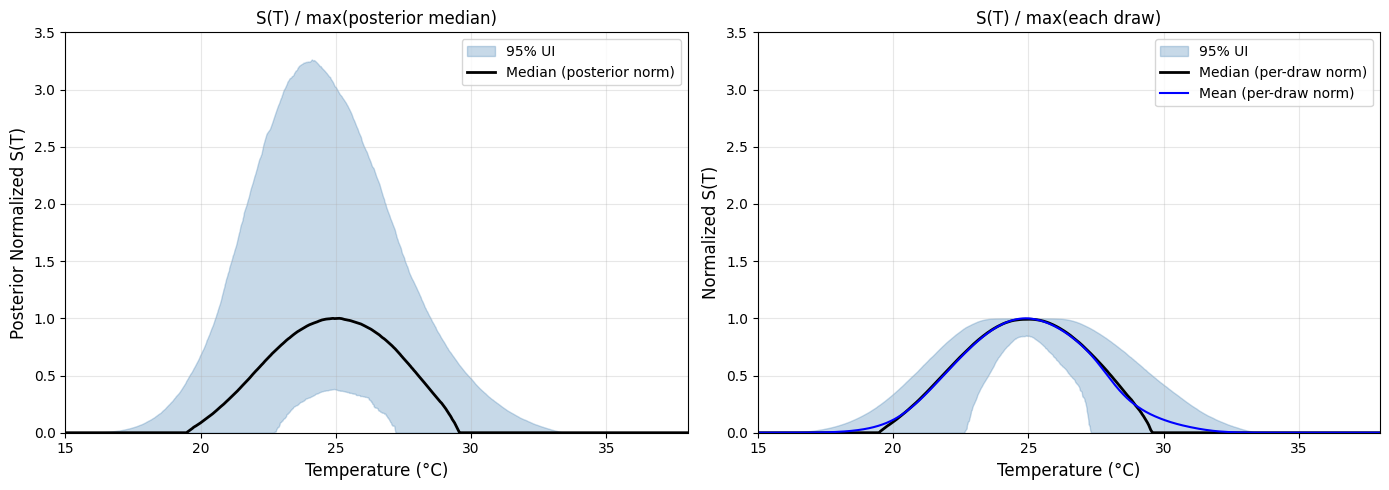

In [6]:
# Two-panel plot comparing normalization approaches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compute statistics for both
pn_median = ds['posterior_normalized_ST'].median(dim='draw')
pn_lower = ds['posterior_normalized_ST'].quantile(0.025, dim='draw')
pn_upper = ds['posterior_normalized_ST'].quantile(0.975, dim='draw')

n_median = ds['normalized_ST'].median(dim='draw')
n_mean = ds['normalized_ST'].mean(dim='draw')
n_mean = n_mean / np.nanmax(n_mean)  # scale mean to max of mean for better comparison
tmp_suit_df = pd.DataFrame({'temperature': T_suit, 'rel_suit': n_mean.values, 'method': 'villena'})
baseline_suit_df = pd.concat([baseline_suit_df, tmp_suit_df], ignore_index=True)
n_lower = ds['normalized_ST'].quantile(0.025, dim='draw')
n_upper = ds['normalized_ST'].quantile(0.975, dim='draw')

# Left panel: posterior_normalized_ST
ax = axes[0]
ax.fill_between(T_suit, pn_lower, pn_upper, alpha=0.3, color='steelblue', label='95% UI')
ax.plot(T_suit, pn_median, 'k-', lw=2, label='Median (posterior norm)')
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Posterior Normalized S(T)', fontsize=12)
ax.set_title('S(T) / max(posterior median)', fontsize=12)
ax.set_xlim(15, 38)
ax.set_ylim(0, 3.5)
ax.legend()
ax.grid(alpha=0.3)

# Right panel: normalized_ST (each draw scaled 0-1)
ax = axes[1]
ax.fill_between(T_suit, n_lower, n_upper, alpha=0.3, color='steelblue', label='95% UI')
ax.plot(T_suit, n_median, 'k-', lw=2, label='Median (per-draw norm)')
ax.plot(T_suit, n_mean, 'b-', lw=1.5, label='Mean (per-draw norm)')
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Normalized S(T)', fontsize=12)
ax.set_title('S(T) / max(each draw)', fontsize=12)
ax.set_xlim(15, 38)
ax.set_ylim(0, 3.5)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
def gething_n_t(T, phi=92.95, T_min=15.56):
    """Calculate n(T) using the gething model formula."""
    if T < T_min:
        return 0.0
    else:
        return phi / (T - T_min)
def gething_g_t(T, a=-4.4, b=1.31, c=-0.03):
    """Calculate g(T) using the gething model formula."""
    return 1 / (a + b * T + c * T**2)
def gething_z_t(T, a=-4.4, b=1.31, c=-0.03, phi=92.95, T_min=15.56):
    """Calculate z(T) using the gething model formula with overflow protection."""
    if T < T_min:
        return 0.0
    
    n_T = gething_n_t(T, phi, T_min)
    g_T = gething_g_t(T, a, b, c)
    
    if g_T <= 0:
        return 0.0
    else:
        # log_num = -n_T * g_T
        # log_den = 2 * np.log(g_T)
        # log_z = log_num - log_den
        # return np.exp(log_z)
        return np.exp(-n_T * g_T) / (g_T ** 2)

/tmp/ipykernel_804486/1663268419.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  return phi / (T - T_min)


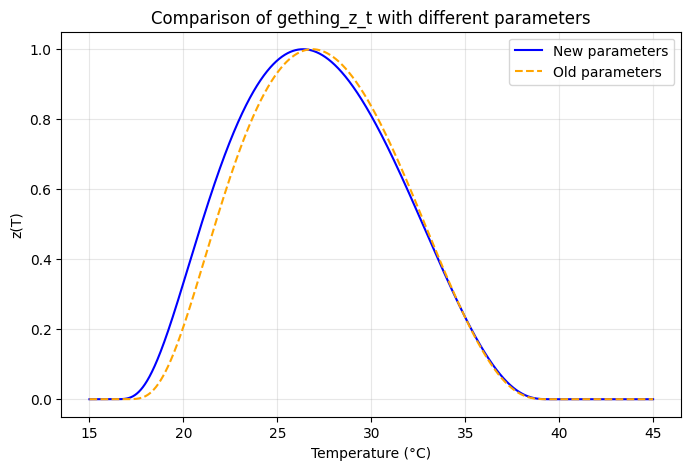

In [8]:
# Compare new and old parameters for gething_z_t
z_new = np.array([gething_z_t(T) for T in T_suit])
z_new = z_new / np.max(z_new)  # Normalize to max of 1 for comparison
tmp_suit_df = pd.DataFrame({'temperature': T_suit, 'rel_suit': z_new, 'method': 'symons'})
baseline_suit_df = pd.concat([baseline_suit_df, tmp_suit_df], ignore_index=True)

z_old = np.array([gething_z_t(T, phi = 111, T_min = 16) for T in T_suit])
z_old = z_old / np.max(z_old)  # Normalize to max of 1 for comparison
plt.figure(figsize=(8, 5))
plt.plot(T_suit, z_new, label='New parameters', color='blue')
plt.plot(T_suit, z_old, label='Old parameters', color='orange', linestyle='--')
plt.xlabel('Temperature (°C)')
plt.ylabel('z(T)')
plt.title('Comparison of gething_z_t with different parameters')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
shifts = [-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0] # Must be multiples of delta_t (1 / 100 = 0.01) for proper shifting
methods = ['mordecai', 'villena', 'symons']
METHOD_LABELS = {
    'mordecai': 'Mordecai (Original)',
    'villena': 'Villena (Reviewer)',
    'symons': 'Symons (MAP)',
}

final_baseline_suit_df = baseline_suit_df.copy()  # Start with baseline data
final_baseline_suit_df['shift'] = 0.0  # Add shift column to baseline for consistency

all_dfs = [final_baseline_suit_df]

for method in methods:
    method_df = final_baseline_suit_df[final_baseline_suit_df['method'] == method].copy().sort_values('temperature').reset_index(drop=True)
    
    for shift in shifts:
        if shift == 0.0:
            continue  # Skip the original (already included)
        row_shift = int(shift / delta_t)
        tmp_df = method_df.copy()
        tmp_df['shift'] = shift
        tmp_df['rel_suit'] = tmp_df['rel_suit'].shift(row_shift, fill_value=0.0)
        all_dfs.append(tmp_df)

full_suit_df = pd.concat(all_dfs, ignore_index=True)
full_suit_df['method'] = pd.Categorical(full_suit_df['method'])

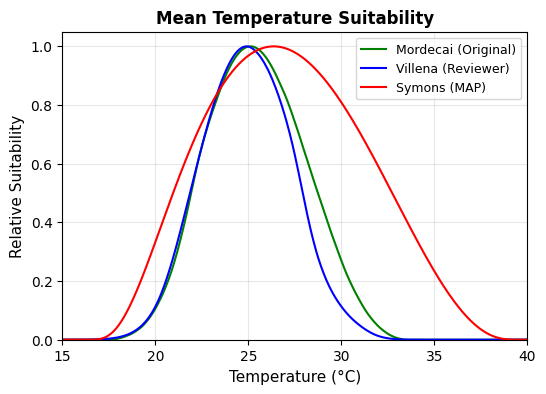

In [17]:
# Create one plot with the zero shift version of each method
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
colors = ['green', 'blue', 'red']

for i, (method, color) in enumerate(zip(methods,colors)):
    method_df = full_suit_df[full_suit_df['method'] == method]
    shift_df = method_df[method_df['shift'] == 0]
    ax.plot(shift_df['temperature'], shift_df['rel_suit'], 
            color=color, lw=1.5, 
            label=f'{METHOD_LABELS[method]}')
    
    ax.set_xlabel('Temperature (°C)', fontsize=11)
    ax.set_ylabel('Relative Suitability', fontsize=11)
    ax.set_title('Mean Temperature Suitability', fontsize=12, fontweight='bold')
    ax.set_xlim(15, 40)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

# plt.tight_layout()
plt.show()

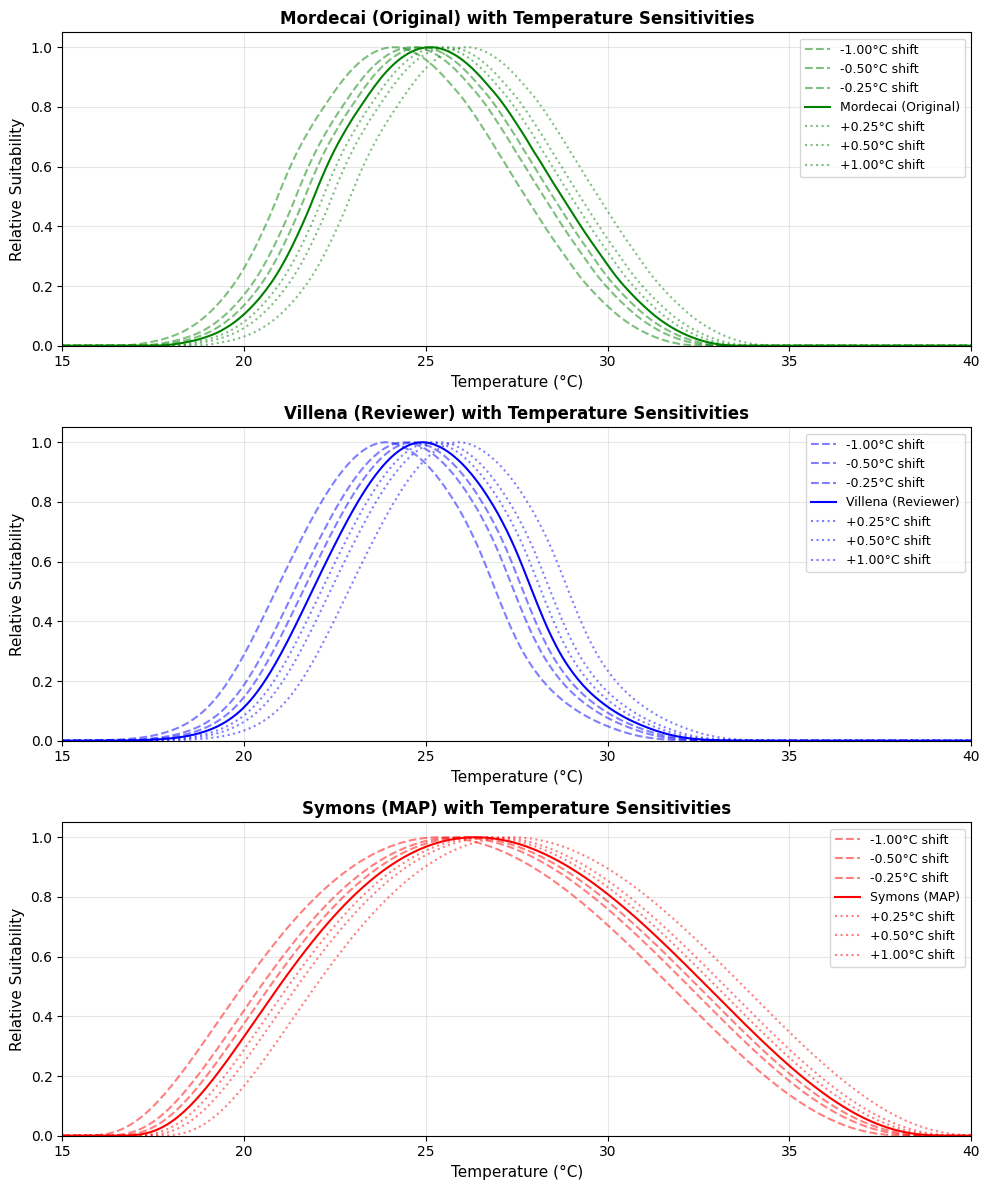

In [11]:
# Create 3x1 panel plot with each method and its sensitivities
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
colors = ['green', 'blue', 'red']

for i, (method, color) in enumerate(zip(methods,colors)):
    ax = axes[i]
    method_df = full_suit_df[full_suit_df['method'] == method]
    for shift in shifts:
        shift_df = method_df[method_df['shift'] == shift]
        linestyle = '--' if shift < 0 else (':' if shift > 0 else '-')
        alpha = 0.5 if shift != 0 else 1.0
        ax.plot(shift_df['temperature'], shift_df['rel_suit'], 
                color=color, lw=1.5, alpha=alpha, linestyle=linestyle,
                label=f'{shift:+.2f}°C shift' if shift != 0 else f'{METHOD_LABELS[method]}')
    
    
    ax.set_xlabel('Temperature (°C)', fontsize=11)
    ax.set_ylabel('Relative Suitability', fontsize=11)
    ax.set_title(f'{METHOD_LABELS[method]} with Temperature Sensitivities', fontsize=12, fontweight='bold')
    ax.set_xlim(15, 40)
    ax.set_ylim(0, None)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
full_suit_df.to_parquet(full_suit_df_path, index=False)